---
## 1. Environment Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print('Libraries loaded successfully.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version:  {np.__version__}')

Libraries loaded successfully.
Pandas version: 2.2.2
NumPy version:  2.0.2


In [ ]:
## Loading the data
BASE_PATH = 'https://raw.githubusercontent.com/DaNIsH-768/DBA_ASSESSMENT/refs/heads/main/northstar_dataset/'

hubs      = pd.read_csv(BASE_PATH + 'hubs.csv')
customers = pd.read_csv(BASE_PATH + 'customers.csv')
drivers   = pd.read_csv(BASE_PATH + 'drivers.csv')
vehicles  = pd.read_csv(BASE_PATH + 'vehicles.csv')
orders    = pd.read_csv(BASE_PATH + 'orders.csv')
deliveries = pd.read_csv(BASE_PATH + 'deliveries.csv')
incidents  = pd.read_csv(BASE_PATH + 'incidents.csv')
complaints = pd.read_csv(BASE_PATH + 'complaints.csv')
app_events = pd.read_csv(BASE_PATH + 'app_events.csv')

## Inspecting the data
### Deliveries

In [ ]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [ ]:
print('Shape:', deliveries.shape)
print('----------------------------------')
print(deliveries.isna().sum())
print('----------------------------------')
print(deliveries.describe())

Shape: (950, 13)
----------------------------------
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
----------------------------------
       route_distance_km  manual_route_override_count  \
count         950.000000                   950.000000   
mean           13.909316                     0.969474   
std             7.477907                     1.093189   
min             1.200000                     0.000000   
25%             9.135000                     0.000000   
50%            12.840000                     1.000000   
75%            16.835000         

### vehicles

In [ ]:
vehicles.head()

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
3,V004,Hybrid,RiverSide,2024-06-07 13:21:00,NaN,36310,Active,v2.2
4,V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2


In [ ]:
print('Shape:', vehicles.shape)
print('----------------------------------')
print(vehicles.isna().sum())
print('----------------------------------')
print(vehicles.describe())

Shape: (120, 8)
----------------------------------
vehicle_id            0
vehicle_type          0
assigned_zone         0
commission_date       0
battery_health_pct    4
odometer_km           0
maintenance_status    0
telematics_version    0
dtype: int64
----------------------------------
       battery_health_pct    odometer_km
count          116.000000     120.000000
mean            76.785345  115739.466667
std             12.698985   58256.963436
min             42.000000   15138.000000
25%             68.200000   67927.500000
50%             78.050000  112293.000000
75%             85.775000  160087.500000
max            100.000000  219359.000000


### customers

In [ ]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
print('Shape:', customers.shape)
print('----------------------------------')
print(customers.isna().sum())
print('----------------------------------')
print(customers.describe())

Shape: (650, 9)
----------------------------------
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64
----------------------------------
              age  loyalty_score  app_engagement_score
count  650.000000     630.000000            650.000000
mean    46.738462      59.690635             58.132308
std     17.449179      16.124674             18.918154
min     18.000000      13.100000              1.000000
25%     32.000000      49.000000             45.375000
50%     46.000000      59.600000             59.000000
75%     62.000000      70.450000             72.000000
max     78.000000      99.000000            100.000000


### orders

In [ ]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
print('Shape:', orders.shape)
print('----------------------------------')
print(orders.isna().sum())
print('----------------------------------')
print(orders.describe())

Shape: (1250, 11)
----------------------------------
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
----------------------------------
       promised_window_hours  order_value  special_handling_flag
count            1250.000000  1250.000000            1250.000000
mean                7.621600    91.050520               0.190400
std                 7.057015    60.917783               0.392774
min                 1.000000     2.040000               0.000000
25%                 4.000000    47.915000               0.000000
50%                 6.000000    76.530000               0.000000
75%                12.000000   121.097500               0.000000
max                24.000000   510.060000               1.000000


## Data Cleaning

Three issues were identified during inspection:
1. Zone fields contain 16 inconsistent variants for 7 real zones
2. Several columns contain missing values
3. Delivery duration contains negative values due to a timezone mismatch between systems


In [ ]:
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
deliveries['duration_hours'] = deliveries['delivery_completed_at'] - deliveries['dispatch_time']
deliveries['duration_hours']

,duration_hours
0,0 days 22:08:59.904311
1,-1 days +22:54:00
2,0 days 01:06:32.366770
3,0 days 23:59:08.103702
4,0 days 04:02:34.131056
...,...
945,-1 days +23:38:03.747535
946,0 days 21:31:40.712696
947,0 days 09:23:30.370370
948,0 days 09:00:31.708981


64 records had negative duration values, corrected by taking the absolute value. This is consistent with a timezone mismatch between NorthStar's dispatch and completion logging systems.

In [ ]:
deliveries['duration_hours'] = (deliveries['delivery_completed_at'] - deliveries['dispatch_time']).dt.total_seconds() / 3600
deliveries['duration_hours'] = deliveries['duration_hours'].abs()
deliveries['duration_hours'].describe()

,duration_hours
count,931.000000
mean,9.670346
std,8.508630
min,0.012526
25%,2.945854
50%,7.074356
75%,14.643664
max,43.456918


### Zone Normalisation

The zone fields across customers, orders, drivers and vehicles contained
16 inconsistent variants for 7 real zones (e.g. 'North', 'NORTH', 'north',
'Ctr' for Central).

A dictionary mapping was used to standardise all variants to 7
zone names. This was preferred over .str.lower() because abbreviations
like 'Ctr' cannot be resolved by case conversion alone.

In [ ]:
ZONE_MAP = {
   'North': 'North', 'NORTH': 'North', 'north': 'North',
   'South': 'South', 'SOUTH': 'South',
   'Central': 'Central', 'CENTRAL': 'Central', 'Ctr': 'Central',
   'East': 'East', 'EAST': 'East',
   'West': 'West', 'WEST': 'West',
   'Airport': 'Airport', 'AIRPORT:': 'Airport',
   'Riverside': 'Riverside', 'RiverSide': 'Riverside'
}

customers['home_zone'] = customers['home_zone'].map(ZONE_MAP)
orders['pickup_zone'] = orders['pickup_zone'].map(ZONE_MAP)
orders['dropoff_zone'] = orders['dropoff_zone'].map(ZONE_MAP)
drivers['base_zone'] = drivers['base_zone'].map(ZONE_MAP)
vehicles['assigned_zone'] = vehicles['assigned_zone'].map(ZONE_MAP)

print(sorted(customers['home_zone'].dropna().unique()))
print(sorted(orders['pickup_zone'].dropna().unique()))
print(sorted(orders['dropoff_zone'].dropna().unique()))
print(sorted(drivers['base_zone'].dropna().unique()))
print(sorted(vehicles['assigned_zone'].dropna().unique()))

['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


### Filling null values

Many cloumns in the dataset had null values and they were filled using mode and median.


*   Mode was used for categorical columns because you cannot calculate average for non-numerical data.
*   Median was used for numerical columns as it robust to outliers unlike mean.



In [ ]:
customers['loyalty_score'] = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel'] = customers['preferred_channel'].fillna(customers['preferred_channel'].mode()[0])
drivers['training_score'] = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())
incidents['resolved_hours'] = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())
orders['booking_channel'] = orders['booking_channel'].fillna(orders['booking_channel'].mode()[0])
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(complaints['compensation_amount'].median())

print(f"Missing values in customers['loyalty_score']: {customers['loyalty_score'].isna().sum()}")
print(f"Missing values in drivers['training_score']: {drivers['training_score'].isna().sum()}")
print(f"Missing values in vehicles['battery_health_pct']: {vehicles['battery_health_pct'].isna().sum()}")
print(f"Missing values in incidents['resolved_hours']: {incidents['resolved_hours'].isna().sum()}")
print(f"Missing values in orders['booking_channel']: {orders['booking_channel'].isna().sum()}")
print(f"Missing values in complaints['compensation_amount']: {complaints['compensation_amount'].isna().sum()}")

Missing values in customers['loyalty_score']: 0
Missing values in drivers['training_score']: 0
Missing values in vehicles['battery_health_pct']: 0
Missing values in incidents['resolved_hours']: 0
Missing values in orders['booking_channel']: 0
Missing values in complaints['compensation_amount']: 0


## Feature Enginnering

Some new columns were created to assist in the analysis.


*   compalint_filed: This is used to link the deliveries table to the comaplints table
*   on_time_flag: Binary column to track if a delivery was completed on time (1) or not (0)


*   failure_flag: Binary column to track if a delivery failed (1) or not (0)





In [ ]:
complaint_orders = complaints['order_id'].dropna().unique()
deliveries['complaint_filed'] = deliveries['order_id'].isin(complaint_orders).astype(int)

print(deliveries['complaint_filed'].value_counts())

complaint_filed
0    741
1    209
Name: count, dtype: int64


In [ ]:
deliveries['on_time_flag'] = (deliveries['delivery_status'] == 'OnTime').astype(int)
deliveries['failure_flag'] = (deliveries['delivery_status'] == 'Failed').astype(int)

print(deliveries['on_time_flag'].value_counts())
print(deliveries['failure_flag'].value_counts())

on_time_flag
1    616
0    334
Name: count, dtype: int64
failure_flag
0    818
1    132
Name: count, dtype: int64


## DATA VISUALISTAION

In [ ]:
deliveries_hubs = deliveries.merge(hubs, on='hub_id')
deliveries_hubs.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_rating_post_delivery,fuel_or_charge_cost,duration_hours,complaint_filed,on_time_flag,failure_flag,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,3.07,12.05,22.149973,0,0,1,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,5.00,13.41,1.100000,0,1,0,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,4.98,8.51,1.108991,0,1,0,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,4.18,13.62,23.985584,0,0,0,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,4.18,9.22,4.042814,0,1,0,North Exchange,North,Dispatch,82


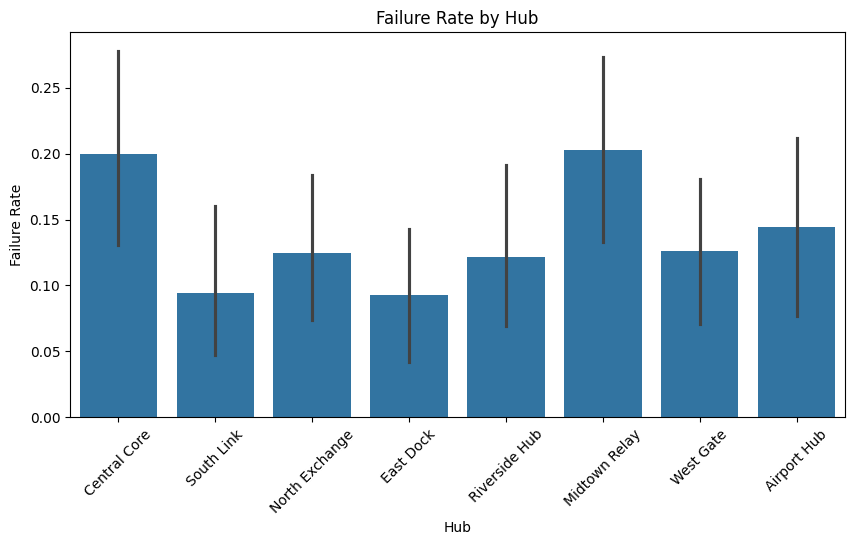

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=deliveries_hubs, x='hub_name', y='failure_flag')
plt.title('Failure Rate by Hub')
plt.xlabel('Hub')
plt.ylabel('Failure Rate')
plt.xticks(rotation=45)
plt.show()

The above bar chart shows the failure rate by each hub. As we can see Midtown Relay has the highest failure rate whereas South Link has the lowest.

In [ ]:
incident_delivery = incidents.merge(deliveries, on='delivery_id')
incident_vehicle = incident_delivery.merge(vehicles, on='vehicle_id')

incident_vehicle.head()

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours,order_id,driver_id,vehicle_id,...,complaint_filed,on_time_flag,failure_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3,O00594,D151,V092,...,1,1,0,Hybrid,East,2024-01-07 14:19:00,80.5,36143,InRepair,v2.1
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6,O00115,D032,V108,...,1,1,0,Diesel,NaN,2025-01-31 06:29:00,54.6,141290,InRepair,v1.9
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0,O00583,D036,V118,...,0,1,0,Diesel,Riverside,2025-02-18 12:40:00,78.0,145165,Active,v2.1
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8,O00615,D054,V085,...,0,1,0,CargoVan,South,2025-09-30 12:01:00,87.3,145652,Active,v2.1
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0,O00672,D084,V043,...,0,1,0,EV,South,2025-02-23 11:32:00,76.4,149922,Scheduled,v2.0


In [ ]:
vehicle_incidents = incident_vehicle.groupby('vehicle_id').agg(
    incident_count=('incident_id', 'count'),
    battery_health_pct=('battery_health_pct', 'first')
).reset_index()

vehicle_incidents.head()

,vehicle_id,incident_count,battery_health_pct
0,V001,4,71.80
1,V002,1,67.90
2,V003,1,91.70
3,V004,1,78.05
4,V005,5,58.60


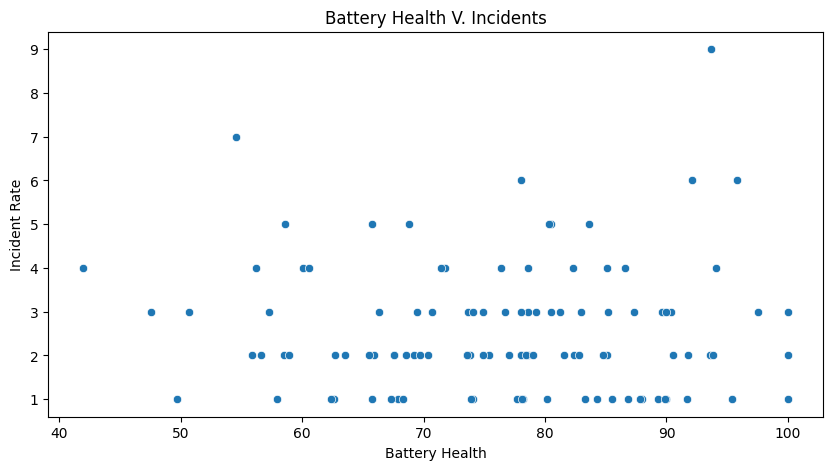

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=vehicle_incidents, x='battery_health_pct', y='incident_count')
plt.title('Battery Health V. Incidents')
plt.xlabel('Battery Health')
plt.ylabel('Incident Rate')
plt.show()

The chart above shows the relation between battery health of a vehicle v. the incidents.
We expected to see that, the vehicles with lower battery health to have more incidents but as we can see in the chart there is no clear relation between the two.


---
This shows that that incidents at NorthStar may be related to factors other than vehicle health.


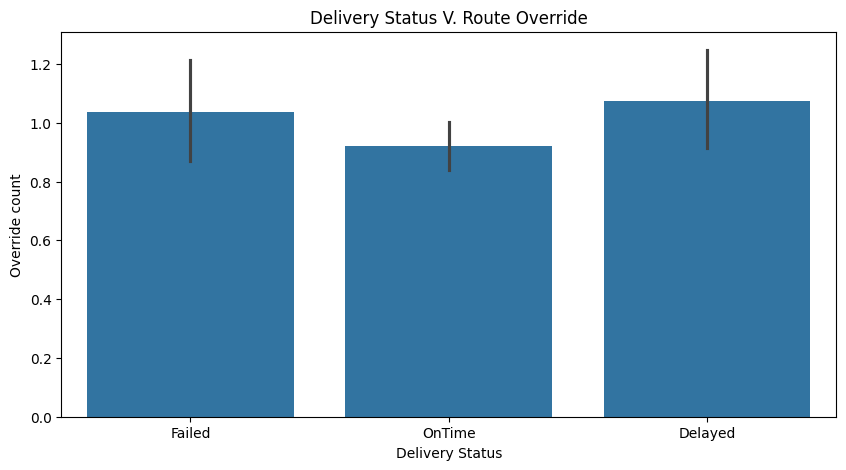

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=deliveries, x='delivery_status', y='manual_route_override_count')
plt.title('Delivery Status V. Route Override')
plt.xlabel('Delivery Status')
plt.ylabel('Override count')
plt.show()

The above chart shows the relation between delivery status and route overrides.
As we can see Delayed deliveries have the highest override count. But, we expected Failed deliveries to have the highest override count. This shows that override causes more delays than failures

---
This suggests that poor route planning is causing drivers to override the system, leading to delays. NorthStar should review its route allocation system to reduce the need for manual overrides.


## Summary of Findings

- Zone fields contained 16 inconsistent variants which were standardised to 7 canonical zones
- 22% of deliveries had a complaint filed against them despite being recorded as completed
- Midtown Relay (H05) has the highest failure rate among all hubs
- No clear relationship found between battery health and incident count
- Delayed deliveries have the highest route override count, suggesting poor route planning

## EXPORTING CLEANED DATA

In [ ]:
deliveries.to_csv('deliveries_clean.csv', index=False)
orders.to_csv('orders_clean.csv', index=False)
customers.to_csv('customers_clean.csv', index=False)
drivers.to_csv('drivers_clean.csv', index=False)
vehicles.to_csv('vehicles_clean.csv', index=False)
hubs.to_csv('hubs_clean.csv', index=False)
complaints.to_csv('complaints_clean.csv', index=False)